Выполнение практического задания 2. 6 вариант

Устанавливаем и подключаем библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from matplotlib.patches import Ellipse, Polygon, Arc
from matplotlib.colors import LinearSegmentedColormap

Загружаем часть данных для ознакомления

In [2]:
df_raw = pd.read_csv('bldg-MC2.csv', nrows=5)

print("Первые 5 строк:")
#print(df_raw)

print("Имена колонок:")
#print(df_raw.columns.tolist())

print("Типы данных:")
#print(df_raw.dtypes)

Первые 5 строк:
Имена колонок:
Типы данных:


Загружаем данные полностью, сразу создаем отдельную колонку только с датой для выполнения задания, выделяем колонки для варианта 6

In [5]:
df = pd.read_csv('bldg-MC2.csv', parse_dates=['Date/Time'], skipinitialspace=True)
df['Date'] = df['Date/Time'].dt.date

var_cols = [col for col in df.columns if col.startswith('F_2_Z_2')]
print(f"F_2_Z_2: {len(var_cols)}")
print(var_cols)

F_2_Z_2: 10
['F_2_Z_2: Lights Power', 'F_2_Z_2: Equipment Power', 'F_2_Z_2: Thermostat Temp', 'F_2_Z_2: Thermostat Heating Setpoint', 'F_2_Z_2: Thermostat Cooling Setpoint', 'F_2_Z_2 VAV REHEAT Damper Position', 'F_2_Z_2 REHEAT COIL Power', 'F_2_Z_2 RETURN OUTLET CO2 Concentration', 'F_2_Z_2 SUPPLY INLET Temperature', 'F_2_Z_2 SUPPLY INLET Mass Flow Rate']


C:\Users\betha\AppData\Local\Temp\ipykernel_54836\3875737229.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Date'] = df['Date/Time'].dt.date


Выполним анализ параметров: рассчитаем статистики для каждой переменной

In [87]:
print(df[var_cols].info())

<class 'pandas.DataFrame'>
RangeIndex: 4032 entries, 0 to 4031
Data columns (total 10 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   F_2_Z_2: Lights Power                    4032 non-null   float64
 1   F_2_Z_2: Equipment Power                 4032 non-null   float64
 2   F_2_Z_2: Thermostat Temp                 4032 non-null   float64
 3   F_2_Z_2: Thermostat Heating Setpoint     4032 non-null   float64
 4   F_2_Z_2: Thermostat Cooling Setpoint     4032 non-null   float64
 5   F_2_Z_2 VAV REHEAT Damper Position       4032 non-null   float64
 6   F_2_Z_2 REHEAT COIL Power                4032 non-null   float64
 7   F_2_Z_2 RETURN OUTLET CO2 Concentration  4032 non-null   float64
 8   F_2_Z_2 SUPPLY INLET Temperature         4032 non-null   float64
 9   F_2_Z_2 SUPPLY INLET Mass Flow Rate      4032 non-null   float64
dtypes: float64(10)
memory usage: 315.1 KB
None


In [9]:
pd.set_option('display.max_columns', None)
print(df[var_cols].describe())

       F_2_Z_2: Lights Power  F_2_Z_2: Equipment Power  \
count            4032.000000               4032.000000   
mean             1017.130372                914.427690   
std              1212.893016                679.220067   
min                 0.000000                344.834700   
25%                 0.000000                344.834700   
50%                 0.000000                344.834700   
75%              2463.104900               1724.173400   
max              2463.104900               1724.173400   

       F_2_Z_2: Thermostat Temp  F_2_Z_2: Thermostat Heating Setpoint  \
count               4032.000000                           4032.000000   
mean                  24.671853                             20.306964   
std                    1.779022                              4.071933   
min                   19.999800                             12.600000   
25%                   24.001000                             15.600000   
50%                   24.005650        

Все параметры вещественные (float64).

F_2_Z_2: Lights Power - мощность света

F_2_Z_2: Equipment Power - мощность оборудования

F_2_Z_2: Thermostat Temp - температура термостата

F_2_Z_2: Thermostat Heating Setpoint - заданное значение нагрева термостата

F_2_Z_2: Thermostat Cooling Setpoint - заданное значение охлаждения термостата  

F_2_Z_2 VAV REHEAT Damper Position - положение заслонки повторного нагрева VAV

F_2_Z_2 REHEAT COIL Power - мощность катушки повторного нагрева             

F_2_Z_2 RETURN OUTLET CO2 Concentration - концентрация углекислого газа на выходе

F_2_Z_2 SUPPLY INLET Temperature - температура на входе подачи

F_2_Z_2 SUPPLY INLET Mass Flow Rate - массовый расход на входе подачи

По статистикам видно, что разброс между некоторыми параметрами очень большой: какие-то в тысячах измеряются, какие-то в десятках. Чтобы воспользоваться лицами Чернова потребуется преобразовать данные: нормализовать их.

Теперь построим матрицы корреляции для всех дней, чтобы определить атрибуты для лиц Чернвоа. Также дадим короткие названия признакам.

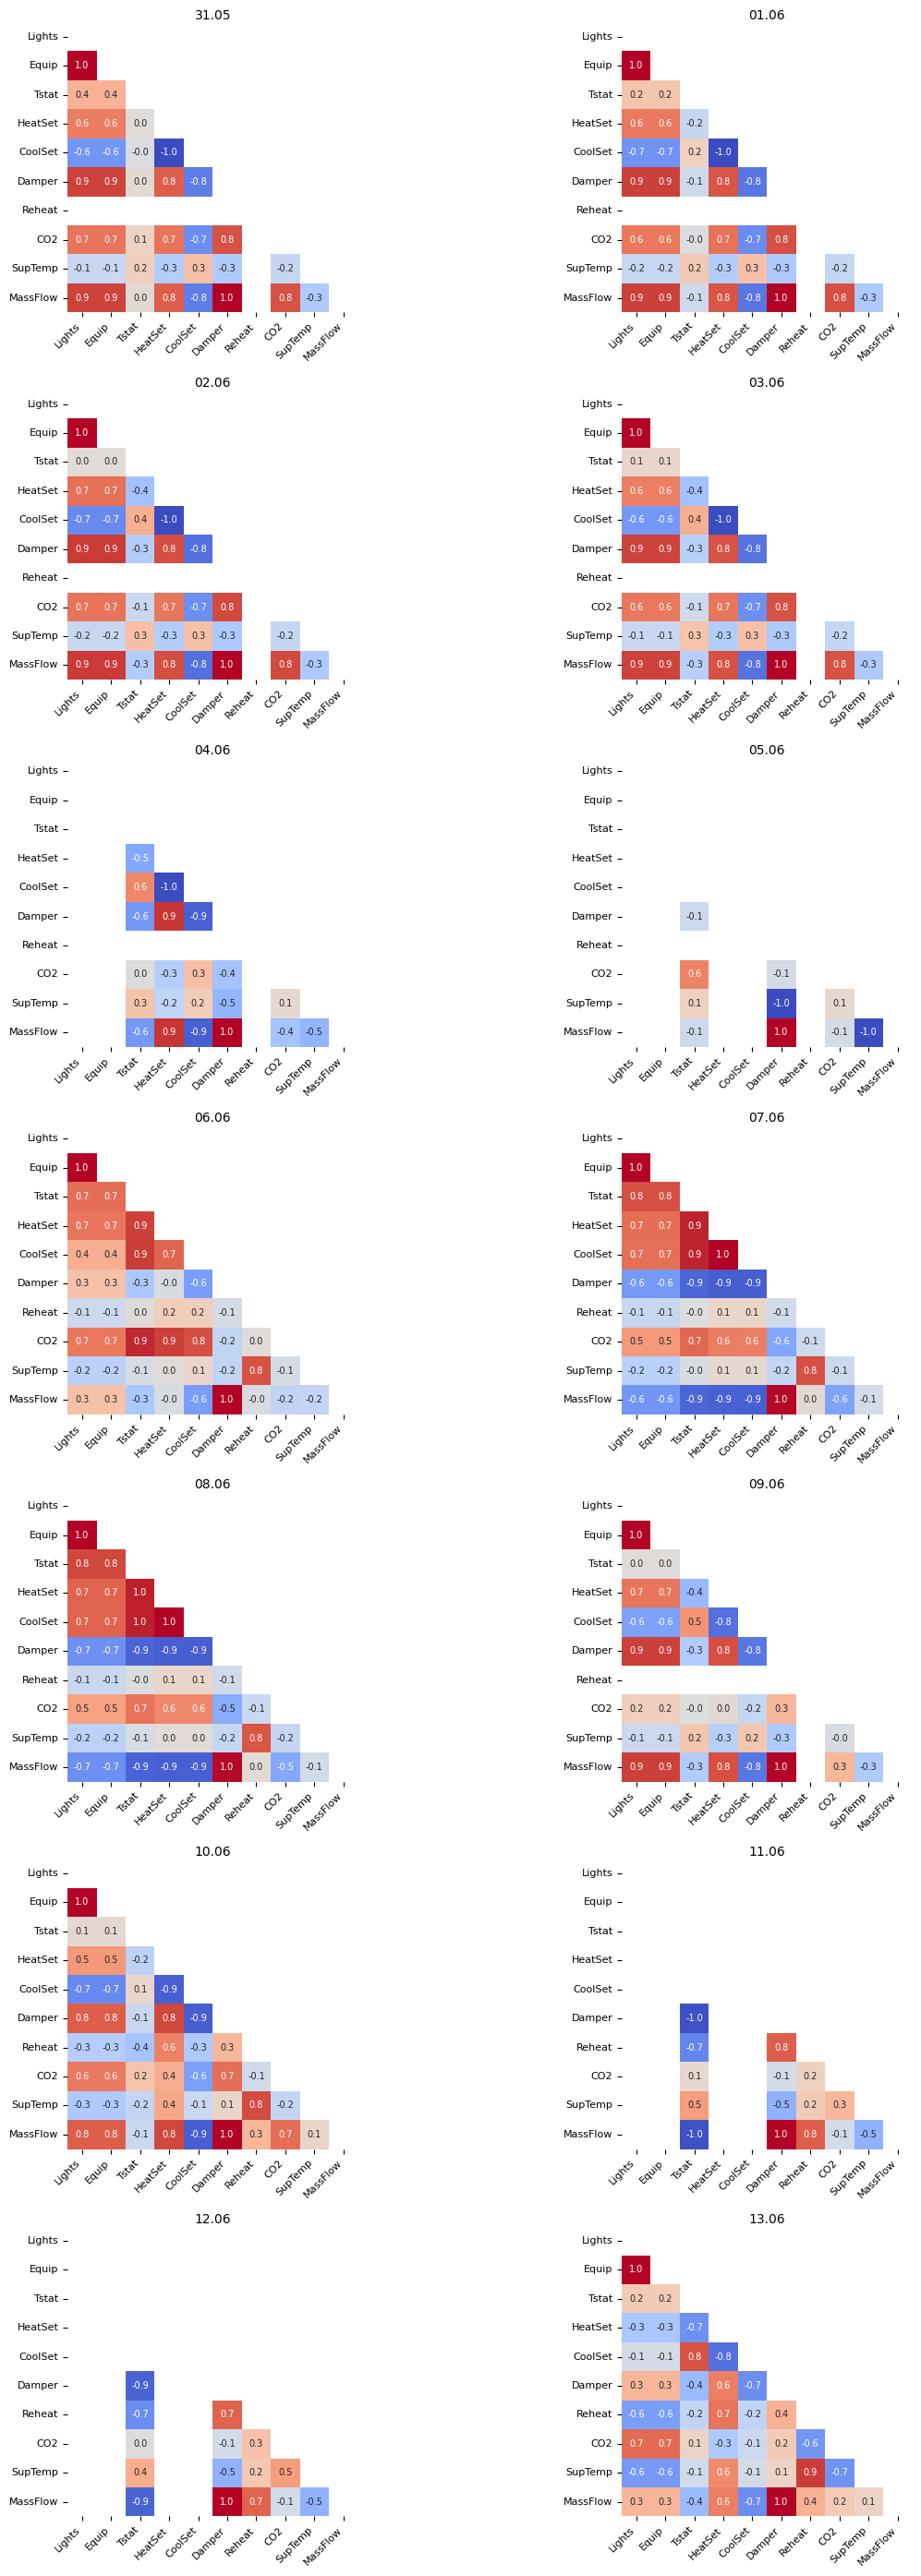

In [89]:
dates = sorted(df['Date'].unique())

daily_corr = {}
for date in dates:
    day_data = df[df['Date'] == date][var_cols]
    daily_corr[date] = day_data.corr()

fig, axes = plt.subplots(7, 2, figsize=(14, 28))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

mask_upper = np.triu(np.ones((len(var_cols), len(var_cols)), dtype=bool), k=0)

short_names = [
    'Lights',    # F_2_Z_2: Lights Power
    'Equip',     # F_2_Z_2: Equipment Power
    'Tstat',     # F_2_Z_2: Thermostat Temp
    'HeatSet',   # F_2_Z_2: Thermostat Heating Setpoint
    'CoolSet',   # F_2_Z_2: Thermostat Cooling Setpoint
    'Damper',    # F_2_Z_2 VAV REHEAT Damper Position
    'Reheat',    # F_2_Z_2 REHEAT COIL Power
    'CO2',       # F_2_Z_2 RETURN OUTLET CO2 Concentration
    'SupTemp',   # F_2_Z_2 SUPPLY INLET Temperature
    'MassFlow'   # F_2_Z_2 SUPPLY INLET Mass Flow Rate
]

for idx, date in enumerate(dates):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    corr = daily_corr[date]
    
    sns.heatmap(corr, ax=ax, mask=mask_upper, cmap='coolwarm', center=0,
                vmin=-1, vmax=1, annot=True, fmt='.1f', cbar=False,
                square=True, xticklabels=short_names, yticklabels=short_names,
                annot_kws={'size': 7})
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    
    ax.set_title(date.strftime('%d.%m'), fontsize=10, pad=2)

for idx in range(len(dates), 14):
    row = idx // 2
    col = idx % 2
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('daily_corr_matrices_with_labels.png', dpi=150, bbox_inches='tight')
plt.show()

Ярко выделяются Lights - Equip, CoolSet - Heatset. У них значение корреляции в основном ~ 1.0 (-1.0), но есть дни когда значение либо отсутствует, либо с противоположным знаком. Чтобы отследить дни, когда возникали аномальные ситуации в системе тепловентилирования и кондиционирования, надо сделать эти пары в лицах Чернова симметричными. 
Есть пара Damper - MassFlow, где значение корреляции во все дни 1.0, а значит никаких аномалий не предвидится и смысла в дублировании нет, поэтому уберем один из признаков, например - Damper. 
Остальные признаки коррелируют достаточно разнообразно, для них нет смысла делать симметричные черты в лицах ЧЕрнова. 

Так как наиболее эффективно воспринимается изменения в размере глаз и наклоне бровей, начнем распределять параметры по важности с них. 

Размер левого глаза - Lights (F_2_Z_2: Lights Power); 
Размер правого глаза - Equip (F_2_Z_2: Equipment Power); 
По отсутствию симметрии глаз сразу будут видны аномальные ситуации, когда мощность освещения и оборудования не совпадают

Изгиб левой брови - HeatSet (F_2_Z_2: Thermostat Heating Setpoint); 
Изгиб правой брови - CoolSet (F_2_Z_2: Thermostat Cooling Setpoint); 
Обе будут изгибаться вверх пропорционально установленному значению нагрева/охлаждения 

Цвет лица - Tstat (F_2_Z_2: Thermostat Temp); 
Будет отображаться более холодная температура, измеряемая термостатом, - голубыми цветами, более теплая - красными

Размер рта - Reheat (F_2_Z_2 REHEAT COIL Power); 
Чем больше рот, тем больше мощность катушки повторного нагрева

Размер носа - CO2 (F_2_Z_2 RETURN OUTLET CO2 Concentration); 
Чем больше нос, тем больше углекислого газа

Цвет волос - SupTemp (F_2_Z_2 SUPPLY INLET Temperature); 
Будет отображаться более холодный приточный воздух - голубыми цветами, более теплый - красными

Длина волос - MassFlow (F_2_Z_2 SUPPLY INLET Mass Flow Rate); 
Чем больше расход приточного воздуха, етм больше длина волос

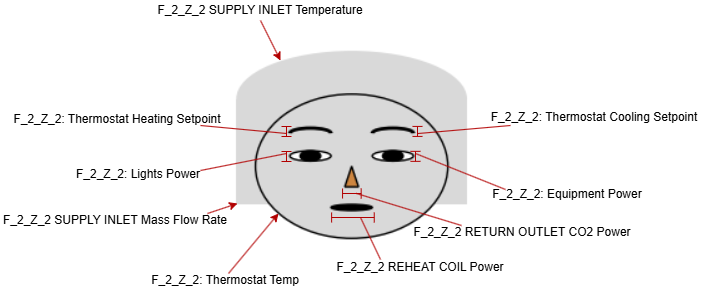

Цветовая палитра основана на желании отобразить температуру, а температура обычно воспринимается как: голубые оттенки - холодно, красные - жарко; серый же выбран нейтралью между ними. Также на схеме выбраны средние значения остальных параметров.


Теперь нормализуем данные, зададим определение лиц Чернова и построим их для 14 дней

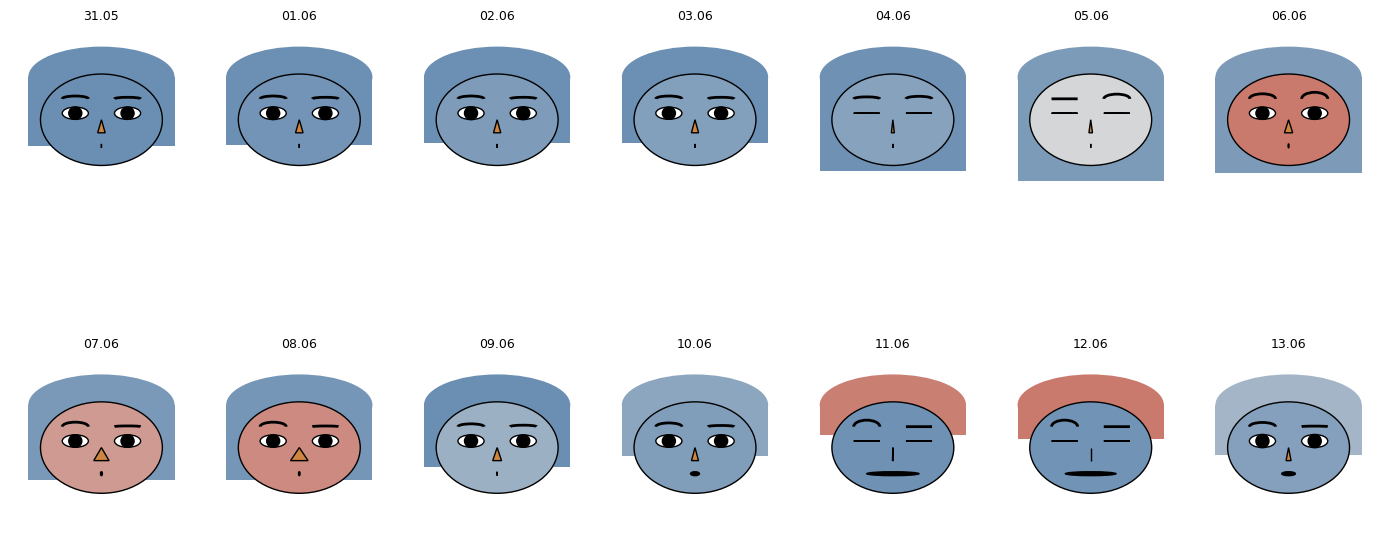

In [110]:
daily_avg = df.groupby('Date')[var_cols].mean()

scaler = MinMaxScaler()
daily_norm = pd.DataFrame(
    scaler.fit_transform(daily_avg),
    index=daily_avg.index,
    columns=daily_avg.columns
)

cmap = LinearSegmentedColormap.from_list(
    "temp",
    ["#6b8fb3", "#d9d9d9", "#c97a6d"]
)

fin_cols = [
    'F_2_Z_2: Lights Power',
    'F_2_Z_2: Equipment Power',
    'F_2_Z_2: Thermostat Temp',
    'F_2_Z_2: Thermostat Heating Setpoint',
    'F_2_Z_2: Thermostat Cooling Setpoint',
    'F_2_Z_2 REHEAT COIL Power',
    'F_2_Z_2 RETURN OUTLET CO2 Concentration',
    'F_2_Z_2 SUPPLY INLET Temperature',
    'F_2_Z_2 SUPPLY INLET Mass Flow Rate'
]

def prepare_face_params(row):
    params = {}
    params['left_eye'] = row['F_2_Z_2: Lights Power']
    params['right_eye'] = row['F_2_Z_2: Equipment Power']
    params['skin_temp'] = row['F_2_Z_2: Thermostat Temp']
    params['left_brow'] = row['F_2_Z_2: Thermostat Heating Setpoint']
    params['right_brow'] = row['F_2_Z_2: Thermostat Cooling Setpoint']
    params['mouth'] = row['F_2_Z_2 REHEAT COIL Power']
    params['nose'] = row['F_2_Z_2 RETURN OUTLET CO2 Concentration']
    params['hair_temp'] = row['F_2_Z_2 SUPPLY INLET Temperature']
    params['hair_flow'] = row['F_2_Z_2 SUPPLY INLET Mass Flow Rate']
    return params

def draw_face(ax, params):
    ax.clear()
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')
    
    face_width = 2.0
    face_height = 1.5
    face_center = (0, 0)
    
    unit_width = face_width / 7
    unit_height = face_height / 7
    
    hair_width = 2.4
    hair_color = cmap(params['hair_temp'])
    
    hair_top_center_y = 0.7
    r_y = 0.5
    
    hair_bottom = hair_top_center_y - r_y - (1 - params['hair_flow']) * 1.2
    
    rect = Polygon([
        (-hair_width/2, hair_bottom),
        (hair_width/2, hair_bottom),
        (hair_width/2, hair_top_center_y),
        (-hair_width/2, hair_top_center_y)
    ], closed=True, fc=hair_color, ec='none', zorder=0)
    ax.add_patch(rect)
    
    ellipse_hair = Ellipse((0, hair_top_center_y), width=hair_width, height=2*r_y,
                           fc=hair_color, ec='none', zorder=0)
    ax.add_patch(ellipse_hair)
    
    skin_color = cmap(params['skin_temp'])
    face = Ellipse(face_center, width=face_width, height=face_height,
                   fc=skin_color, ec='black', linewidth=1, zorder=1)
    ax.add_patch(face)
    
    eye_x_offset = unit_width * 1.5
    eye_y = unit_height / 2
    eye_width = unit_width * 1.5
    
    eye_height_left = unit_height * params['left_eye']
    left_eye = Ellipse((-eye_x_offset, eye_y), width=eye_width, height=eye_height_left,
                       fc='white', ec='black', linewidth=1, zorder=2)
    ax.add_patch(left_eye)
    pupil_left = Ellipse((-eye_x_offset, eye_y), width=eye_width/2, height=eye_height_left,
                         fc='black', ec='black', linewidth=1, zorder=3)
    ax.add_patch(pupil_left)
    
    eye_height_right = unit_height * params['right_eye']
    right_eye = Ellipse((eye_x_offset, eye_y), width=eye_width, height=eye_height_right,
                        fc='white', ec='black', linewidth=1, zorder=2)
    ax.add_patch(right_eye)
    pupil_right = Ellipse((eye_x_offset, eye_y), width=eye_width/2, height=eye_height_right,
                          fc='black', ec='black', linewidth=1, zorder=3)
    ax.add_patch(pupil_right)
    
    brow_y = eye_y + unit_height * 1.1
    brow_width = unit_width * 1.5
    
    brow_height_left = unit_height * params['left_brow']
    if brow_height_left == 0:
        brow_height_left = 0.001
    brow_left = Arc((-eye_x_offset, brow_y), width=brow_width, height=brow_height_left,
                    theta1=0, theta2=180, edgecolor='black', lw=2, zorder=4)
    ax.add_patch(brow_left)
    
    brow_height_right = unit_height * params['right_brow']
    if brow_height_right == 0:
        brow_height_right = 0.001
    brow_right = Arc((eye_x_offset, brow_y), width=brow_width, height=brow_height_right,
                     theta1=0, theta2=180, edgecolor='black', lw=2, zorder=4)
    ax.add_patch(brow_right)
    
    nose_width = unit_width * params['nose']
    nose_height = unit_height
    nose_tip = (0, 0)
    nose_left = (-nose_width/2, -nose_height)
    nose_right = (nose_width/2, -nose_height)
    nose = Polygon([nose_left, nose_right, nose_tip], closed=True,
                   fc='peru', ec='black', lw=1, zorder=2)
    ax.add_patch(nose)
    
    mouth_center = (0, -unit_height * 2)
    mouth_width = unit_width * 3 * params['mouth']
    mouth_height = unit_height * 1.5 * 0.2
    mouth = Ellipse(mouth_center, width=mouth_width, height=mouth_height,
                    fc='black', ec='black', lw=1, zorder=2)
    ax.add_patch(mouth)

dates = sorted(daily_norm.index)[:14]
fig, axes = plt.subplots(2, 7, figsize=(14, 8))
axes = axes.flatten()

for i, date in enumerate(dates):
    row = daily_norm.loc[date]
    params = prepare_face_params(row)
    draw_face(axes[i], params)
    axes[i].set_title(date.strftime('%d.%m'), fontsize=9)

plt.tight_layout()
plt.savefig('chernoff_faces.png', dpi=150, bbox_inches='tight')
plt.show()

Оказалось, что Lights - Equip такие же, как и пара Damper - MassFlow, где значение корреляции во все дни 1.0. У пары Lights - Equip были дни без корреляции, и был сделан неправильный вывод, что, возможно, только одного из этих значений нет, когда на самом деле не было обоих значений - соответсвенно, они идентично отсутствовали и потом идентично присутствовали.

Исправим визуализацию, опустив значение Equip, так как они идентичны с Lights. 
При этом оставим размер обоих глаз - Lights (F_2_Z_2: Lights Power); по открытым/закрытым глазам будет понятно, когда свет и оборудование работали/не работали.

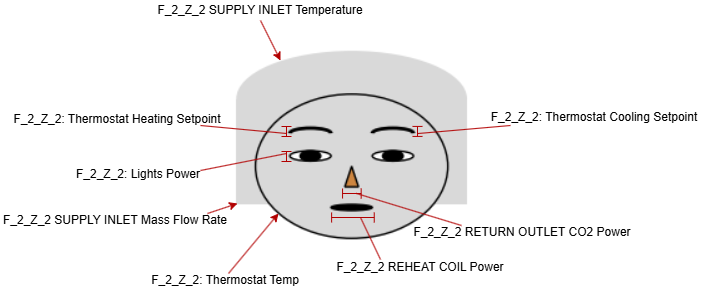


Теперь зададим определение лиц Чернова и построим их для 14 дней

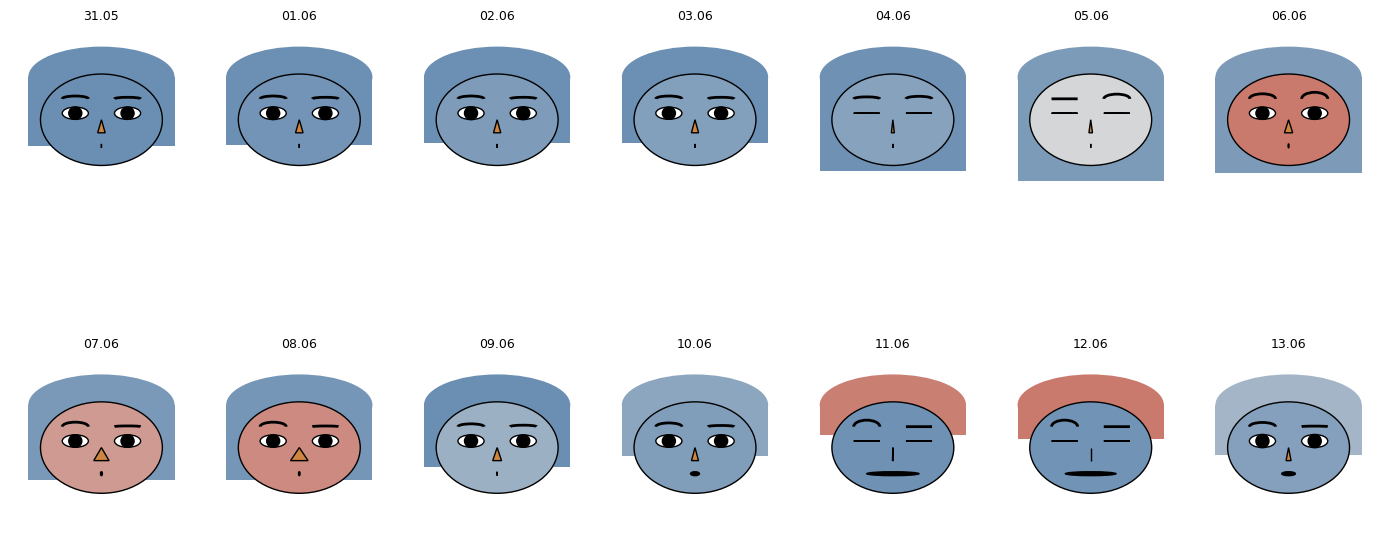

In [111]:
fin_fin_cols = [
    'F_2_Z_2: Lights Power',
    'F_2_Z_2: Thermostat Temp',
    'F_2_Z_2: Thermostat Heating Setpoint',
    'F_2_Z_2: Thermostat Cooling Setpoint',
    'F_2_Z_2 REHEAT COIL Power',
    'F_2_Z_2 RETURN OUTLET CO2 Concentration',
    'F_2_Z_2 SUPPLY INLET Temperature',
    'F_2_Z_2 SUPPLY INLET Mass Flow Rate'
]

def prepare_face_params(row):
    params = {}
    params['eye_size'] = row['F_2_Z_2: Lights Power']
    params['skin_temp'] = row['F_2_Z_2: Thermostat Temp']
    params['left_brow'] = row['F_2_Z_2: Thermostat Heating Setpoint']
    params['right_brow'] = row['F_2_Z_2: Thermostat Cooling Setpoint']
    params['mouth'] = row['F_2_Z_2 REHEAT COIL Power']
    params['nose'] = row['F_2_Z_2 RETURN OUTLET CO2 Concentration']
    params['hair_temp'] = row['F_2_Z_2 SUPPLY INLET Temperature']
    params['hair_flow'] = row['F_2_Z_2 SUPPLY INLET Mass Flow Rate']
    return params

def draw_face(ax, params):
    ax.clear()
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')
    
    face_width = 2.0
    face_height = 1.5
    face_center = (0, 0)
    
    unit_width = face_width / 7
    unit_height = face_height / 7
    
    hair_width = 2.4
    hair_color = cmap(params['hair_temp'])
    
    hair_top_center_y = 0.7
    r_y = 0.5
    
    hair_bottom = hair_top_center_y - r_y - (1 - params['hair_flow']) * 1.2
    
    rect = Polygon([
        (-hair_width/2, hair_bottom),
        (hair_width/2, hair_bottom),
        (hair_width/2, hair_top_center_y),
        (-hair_width/2, hair_top_center_y)
    ], closed=True, fc=hair_color, ec='none', zorder=0)
    ax.add_patch(rect)
    
    ellipse_hair = Ellipse((0, hair_top_center_y), width=hair_width, height=2*r_y,
                           fc=hair_color, ec='none', zorder=0)
    ax.add_patch(ellipse_hair)
    
    skin_color = cmap(params['skin_temp'])
    face = Ellipse(face_center, width=face_width, height=face_height,
                   fc=skin_color, ec='black', linewidth=1, zorder=1)
    ax.add_patch(face)
    
    eye_x_offset = unit_width * 1.5
    eye_y = unit_height / 2
    eye_width = unit_width * 1.5
    eye_height = unit_height * params['eye_size']
    
    left_eye = Ellipse((-eye_x_offset, eye_y), width=eye_width, height=eye_height,
                       fc='white', ec='black', linewidth=1, zorder=2)
    ax.add_patch(left_eye)
    pupil_left = Ellipse((-eye_x_offset, eye_y), width=eye_width/2, height=eye_height,
                         fc='black', ec='black', linewidth=1, zorder=3)
    ax.add_patch(pupil_left)

    right_eye = Ellipse((eye_x_offset, eye_y), width=eye_width, height=eye_height,
                        fc='white', ec='black', linewidth=1, zorder=2)
    ax.add_patch(right_eye)
    pupil_right = Ellipse((eye_x_offset, eye_y), width=eye_width/2, height=eye_height,
                          fc='black', ec='black', linewidth=1, zorder=3)
    ax.add_patch(pupil_right)
    
    brow_y = eye_y + unit_height * 1.1
    brow_width = unit_width * 1.5
    
    brow_height_left = unit_height * params['left_brow']
    if brow_height_left == 0:
        brow_height_left = 0.001
    brow_left = Arc((-eye_x_offset, brow_y), width=brow_width, height=brow_height_left,
                    theta1=0, theta2=180, edgecolor='black', lw=2, zorder=4)
    ax.add_patch(brow_left)
    
    brow_height_right = unit_height * params['right_brow']
    if brow_height_right == 0:
        brow_height_right = 0.001
    brow_right = Arc((eye_x_offset, brow_y), width=brow_width, height=brow_height_right,
                     theta1=0, theta2=180, edgecolor='black', lw=2, zorder=4)
    ax.add_patch(brow_right)
    
    nose_width = unit_width * params['nose']
    nose_height = unit_height
    nose_tip = (0, 0)
    nose_left = (-nose_width/2, -nose_height)
    nose_right = (nose_width/2, -nose_height)
    nose = Polygon([nose_left, nose_right, nose_tip], closed=True,
                   fc='peru', ec='black', lw=1, zorder=2)
    ax.add_patch(nose)
    
    mouth_center = (0, -unit_height * 2)
    mouth_width = unit_width * 3 * params['mouth']
    mouth_height = unit_height * 1.5 * 0.2
    mouth = Ellipse(mouth_center, width=mouth_width, height=mouth_height,
                    fc='black', ec='black', lw=1, zorder=2)
    ax.add_patch(mouth)

dates = sorted(daily_norm.index)[:14]
fig, axes = plt.subplots(2, 7, figsize=(14, 8))
axes = axes.flatten()

for i, date in enumerate(dates):
    row = daily_norm.loc[date]
    params = prepare_face_params(row)
    draw_face(axes[i], params)
    axes[i].set_title(date.strftime('%d.%m'), fontsize=9)

plt.tight_layout()
plt.savefig('chernoff_faces_fin.png', dpi=150, bbox_inches='tight')
plt.show()

Сделаем лицо Чернова среднее за 14 дней, чтобы определить аномалии

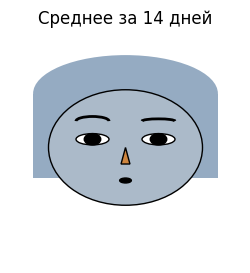

In [114]:
mean_row = daily_norm.mean()
params_mean = prepare_face_params(mean_row)

fig_mean, ax_mean = plt.subplots(figsize=(3, 3))
draw_face(ax_mean, params_mean)
ax_mean.set_title('Среднее за 14 дней')
plt.savefig('mean_face.png', dpi=150, bbox_inches='tight')
plt.show()

На основе выполненного анализа и визуализации сформулируем и обоснуем ответы на поставленные вопросы к набору данных: 

1) Определите, в какие дни возникали аномальные ситуации в системе тепловентилирования и кондиционирования? 
    
    Особо заметны даты 4, 5, 11, 12 июня. Скорее всего это были выходные дни (своеобразные аномальные ситуации), потому что ни свет, ни оборудование не включалось - глаза закрыты. 
    Ярко выраженные на аномалии дни - 5, 6, 7, 8, 11, 12 числа. Аномалии, конечно, разнятся, например: слишком высокое количество углекислого газа, а значит недостаточная вентиляция; или слишком высокое заданное значение нагрева при отсутствии света, включенного оборудования, а значит и людей (зачем вообще система включена?..)

2) Какие параметры связаны с аномалиями?

    По сути все параметры связаны с аномалиями, по большей части не единично, а именно в комбинациях с другими параметрами (комбинаций большое количество). 
    Например, сильный изгиб одной из бровей - это нормально, но если обе брови имеют одинаковый сильный изгиб - это уже аномалия, потому что в "норме" асимметичность этих параметров.

В целом можно сказать, что определенная схема визуализации была удачна, потому что получилось выявить отклонения в функционировании системы.